In [4]:
import json

with open("CUADv1.json", "r", encoding="utf-8") as f:
    cuad = json.load(f)

print(type(cuad))
print(cuad.keys())

<class 'dict'>
dict_keys(['version', 'data'])


In [5]:
print("Version:", cuad["version"])
print("Number of contracts:", len(cuad["data"]))

Version: aok_v1.0
Number of contracts: 510


In [6]:
contract = cuad["data"][0]
print("Keys in a contract:", contract.keys())
print("Title:", contract["title"])
print("Number of paragraphs:", len(contract["paragraphs"]))

Keys in a contract: dict_keys(['title', 'paragraphs'])
Title: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
Number of paragraphs: 1


In [7]:
para = contract["paragraphs"][0]
print("Keys in paragraph:", para.keys())         # 'context', 'qas'
print("Context length (chars):", len(para["context"]))
print("Number of QAs:", len(para["qas"]))         # should be 41


Keys in paragraph: dict_keys(['qas', 'context'])
Context length (chars): 54290
Number of QAs: 41


In [8]:
qa = para["qas"][0]
print("QA keys:", qa.keys())
print("ID:", qa["id"])
print("Question:", qa["question"])
print("Is impossible:", qa["is_impossible"])   # True = clause not found in this contract
print("Answers:", qa["answers"])

QA keys: dict_keys(['answers', 'id', 'question', 'is_impossible'])
ID: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name
Question: Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract
Is impossible: False
Answers: [{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}]


In [9]:
{"text": "<the actual clause text>", "answer_start": 4821}

{'text': '<the actual clause text>', 'answer_start': 4821}

In [10]:
categories = [qa["id"].split("__")[-1] for qa in para["qas"]]
print(len(categories))
for c in categories:
    print(c)

41
Document Name
Parties
Agreement Date
Effective Date
Expiration Date
Renewal Term
Notice Period To Terminate Renewal
Governing Law
Most Favored Nation
Non-Compete
Exclusivity
No-Solicit Of Customers
Competitive Restriction Exception
No-Solicit Of Employees
Non-Disparagement
Termination For Convenience
Rofr/Rofo/Rofn
Change Of Control
Anti-Assignment
Revenue/Profit Sharing
Price Restrictions
Minimum Commitment
Volume Restriction
Ip Ownership Assignment
Joint Ip Ownership
License Grant
Non-Transferable License
Affiliate License-Licensor
Affiliate License-Licensee
Unlimited/All-You-Can-Eat-License
Irrevocable Or Perpetual License
Source Code Escrow
Post-Termination Services
Audit Rights
Uncapped Liability
Cap On Liability
Liquidated Damages
Warranty Duration
Insurance
Covenant Not To Sue
Third Party Beneficiary


In [11]:
for qa in para["qas"]:
    if not qa["is_impossible"]:
        print("Category:", qa["id"].split("__")[-1])
        print("Clause text:", qa["answers"][0]["text"][:300])
        print("-" * 80)
        break

Category: Document Name
Clause text: DISTRIBUTOR AGREEMENT
--------------------------------------------------------------------------------


In [14]:
import pandas as pd

records = []

for doc in cuad["data"]:
    title = doc["title"]
    for para in doc["paragraphs"]:
        for qa in para["qas"]:
            category = qa["id"].split("__")[-1]
            for ans in qa["answers"]:
                records.append({
                    "contract": title,
                    "category": category,
                    "clause_text": ans["text"],
                    "answer_start": ans["answer_start"]
                })

df = pd.DataFrame(records)
print(df.shape)
df.head()

(13823, 4)


,contract,category,clause_text,answer_start
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,DISTRIBUTOR AGREEMENT,44
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Distributor,244
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Electric City Corp.,148
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Electric City of Illinois L.L.C.,49574
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Company,197


In [13]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn


  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl (12.6 MB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py

In [15]:
print(df.shape)        # (total_clauses, 4) — expect somewhere around 13,000+ rows
df.head()               # visually confirm columns look right
df["category"].nunique()  # should be 41

(13823, 4)


41

In [16]:
# find any ids with more than one "__" split, to check category extraction is clean
suspicious = df[df["category"].str.contains("__")]
print(len(suspicious))

0


In [17]:
categories = df["category"].unique()
print(len(categories))
print(categories)

41
<StringArray>
[                     'Document Name',                            'Parties',
                     'Agreement Date',                     'Effective Date',
                    'Expiration Date',                       'Renewal Term',
                      'Governing Law',                        'Exclusivity',
            'No-Solicit Of Customers',            'No-Solicit Of Employees',
                     'Rofr/Rofo/Rofn',                    'Anti-Assignment',
                 'Price Restrictions',                 'Minimum Commitment',
                      'License Grant',          'Post-Termination Services',
                  'Warranty Duration',                          'Insurance',
                'Covenant Not To Sue',                  'Change Of Control',
                       'Audit Rights',                 'Uncapped Liability',
                   'Cap On Liability', 'Notice Period To Terminate Renewal',
        'Termination For Convenience',                     

category
Parties                               2554
License Grant                          777
Cap On Liability                       672
Anti-Assignment                        654
Audit Rights                           643
Insurance                              560
Document Name                          521
Agreement Date                         476
Expiration Date                        467
Governing Law                          464
Post-Termination Services              450
Effective Date                         447
Minimum Commitment                     424
Revenue/Profit Sharing                 418
Exclusivity                            410
Rofr/Rofo/Rofn                         367
Ip Ownership Assignment                318
Non-Transferable License               298
Non-Compete                            259
Change Of Control                      253
Termination For Convenience            246
Renewal Term                           210
Warranty Duration                      176
Co

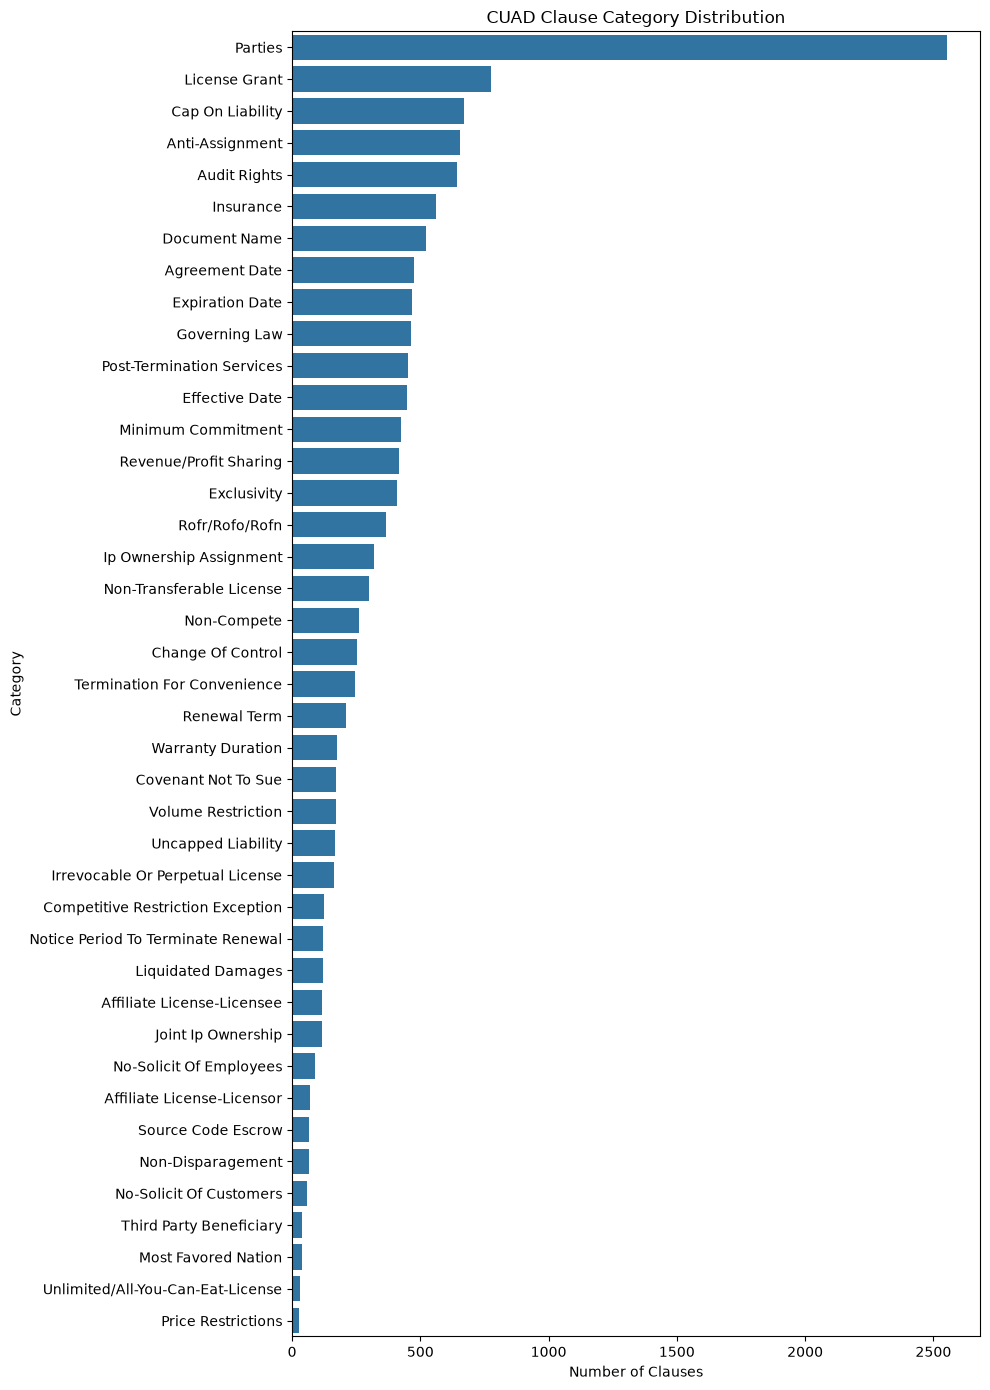

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = df["category"].value_counts()
print(label_counts)

plt.figure(figsize=(10, 14))
sns.barplot(y=label_counts.index, x=label_counts.values)
plt.title("CUAD Clause Category Distribution")
plt.xlabel("Number of Clauses")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [19]:
print("Most common:", label_counts.idxmax(), label_counts.max())
print("Least common:", label_counts.idxmin(), label_counts.min())
print("Imbalance ratio:", label_counts.max() / label_counts.min())

Most common: Parties 2554
Least common: Price Restrictions 27
Imbalance ratio: 94.5925925925926


In [20]:
low_support = label_counts[label_counts < 50]
print(low_support)

category
Third Party Beneficiary              39
Most Favored Nation                  38
Unlimited/All-You-Can-Eat-License    32
Price Restrictions                   27
Name: count, dtype: int64


In [21]:
plt.savefig("category_distribution.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

count    13823.000000
mean        40.678290
std         43.445576
min          1.000000
25%          5.000000
50%         31.000000
75%         57.000000
max        479.000000
Name: clause_length, dtype: float64


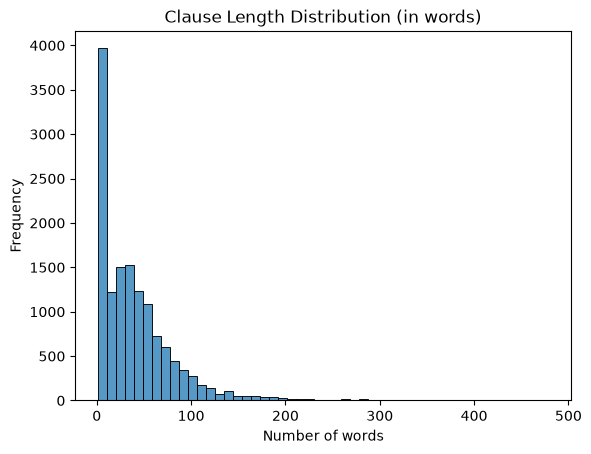

In [22]:
df["clause_length"] = df["clause_text"].apply(lambda x: len(x.split()))
print(df["clause_length"].describe())

sns.histplot(df["clause_length"], bins=50)
plt.title("Clause Length Distribution (in words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

In [23]:
# Shortest clauses — check for noise/artifacts
df.nsmallest(5, "clause_length")[["category", "clause_text", "clause_length"]]

# Longest clauses — check if they're still legitimately single clauses
df.nlargest(5, "clause_length")[["category", "clause_text", "clause_length"]]

,category,clause_text,clause_length
1507,Non-Compete,The Executive agrees and undertakes with the C...,479
9190,Renewal Term,You shall have the option to renew the term of...,461
9269,Source Code Escrow,Storage Fee (payable if the source code exceed...,451
9271,Source Code Escrow,Subject to the provisions of Clauses 6.2 and 6...,404
6642,License Grant,"Subject to Section 3.2, a Licensor Party, on b...",394


In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

with open("CUADv1.json", "r", encoding="utf-8") as f:
    cuad = json.load(f)

In [ ]:
print("Version:", cuad["version"])
print("Number of contracts:", len(cuad["data"]))

contract = cuad["data"][0]
para = contract["paragraphs"][0]
print("Paragraph keys:", para.keys())
print("Number of QAs per contract:", len(para["qas"]))
